Import Landlab + Components + others

In [27]:
# landlab imports
from landlab import RasterModelGrid, imshow_grid
from landlab.components import TidalFlowCalculator
from landlab.plot.graph import plot_graph
from landlab.grid.mappers import map_mean_of_link_nodes_to_link

# other imports
import numpy as np

Create grid

In [2]:
# grid values
num_rows = 100
num_cols = 100
dxy = 50

grid = RasterModelGrid((num_rows, num_cols), dxy, xy_axis_units='m')
# plot_graph(grid, at='cell')

Initialize and visualize topography

In [3]:
# Add a noisy initial topography

np.random.seed(33)
noisy_grid = np.random.rand(grid.number_of_nodes) / 100  # intial noise on elevation grid

# Set-up the elevation field on the grid
z = grid.add_zeros("topographic__elevation", at="node", units = 'm') # always call elevation data "topographic__elevation" -> standard name in landlab
z += noisy_grid

grid.at_node['topographic__elevation'][:] -= 10

In [4]:
grid.set_closed_boundaries_at_grid_edges(True, True, True, False)

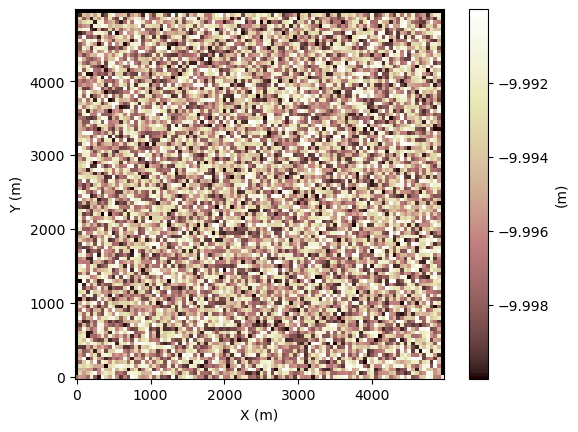

In [5]:
# Plot the elevation map
imshow_grid(grid, "topographic__elevation", var_units = 'm')

## Writing a component for sediment transport

In [ ]:
# 
def calc_deposition(w_s: float, c: float) -> float:
    """ compute deposition 
    
    PARAMETERS
    w_s: settling velocity
    c: sediment concentration"""
        return w_s*c

def calc_shear(grid,v):
""" computes shear stress at links
    
    PARAMETERS
    w_s: settling velocity
    c: sediment concentration"""
    
    rho_w = 1025
    g = 9.81
    n = 1 # mannings n

    # water depth is transferred from nodes to links, v is on links
    shear=rho_w*g*(n**2)*(map_mean_of_link_nodes_to_link(grid, "mean_water__depth"))**(-1/3))*np.sign(v)*(v**2)
    return shear

def calc_erosion(grid,v):
    """ compute erosion 
    
    PARAMETERS
    w_s: settling velocity
    c: sediment concentration

    n: float=1,
    rho_w: 1025 """
    shear_crit = 0.2
    m_e = 0.2

    erosion=m_e * np.sqrt((1+(calc_shear(grid,v)/shear_crit))**2)-1

    return erosion

grid.map_mean_of_link_nodes_to_link


def calc_bed_evolution(grid, dt, mu: float=0.1, rslr=0)->:

    rho_s=2650

    # deposition
    d = calc_deposition()
    # erosion
    e_plus = calc_erosion(grid, v=grid.at_links["flood_tide_flow__velocity"])
    e_min = calc_erosion(calc_erosion(grid, v=grid.at_links["ebb_tide_flow__velocity"]))
    e = (e_plus + e_min)/2
    e_at_nodes = grid.map_sum_of_inlinks_to_node(e) + grid.map_sum_of_outlinks_to_node(e)
    
    dz_dt = grid.calc_flux_div_at_node(mu*grid.calc_grad_at_link(grid.at_node["topographic__elevation"])) + rslr + ((d-e)/rho_s)
    
    return dz_dt

    """

    DEPENDENCIES
    calc_deposition()
    calc_shear()
    calc_erosion()
    
    PARAMETERS
    #u: flow velocity
    #h: water depth
    grid
    dt
    mu: diffusion coefficient
    rslr: relaTiVE SEA LEVEL RISE default 0
    n: Manning's n
    rho_w: water kg/m3
    rho_s: soil
    g: gravity
    
    """

In [20]:
# plot dz/dt

AttributeError: 'RasterModelGrid' object has no attribute 'sum_links_at_node'

In [7]:
# tidal parameters
tidal_range = 2
#tidal_
roughness = 0.01

# create instance
tfc = TidalFlowCalculator(grid, tidal_range=tidal_range, roughness=roughness)

In [9]:
# simulation parameters
#dt = 20 # days


In [10]:
# run model
tfc.run_one_step() 
# output:
# nodes: topographic elevation and mean water depth
# links: tidal flow velocity (ebb/flood)

# --> we need to use an incision component: e.g. fluvial incision?

In [11]:
grid.at_link.keys()

['flood_tide_flow__velocity', 'ebb_tide_flow__velocity']

In [12]:
grid.at_node.keys()

['topographic__elevation', 'mean_water__depth']

In [18]:
grid.at_node["mean_water__depth"]

array([9.9975149 , 9.99550025, 9.99589059, ..., 9.99855747, 9.99345985,
       9.99447409], shape=(10000,))

In [19]:
grid.at_node["topographic__elevation"]

array([-9.9975149 , -9.99550025, -9.99589059, ..., -9.99855747,
       -9.99345985, -9.99447409], shape=(10000,))

In [17]:
# check values at links of field flood tide velocity
grid.at_link["flood_tide_flow__velocity"][30]

np.float64(0.0)

In [16]:
# check values at links of field flood tide velocity
grid.at_link["ebb_tide_flow__velocity"]

array([-0., -0., -0., ..., -0., -0., -0.], shape=(19800,))